# ML Pipeline — GitHub Effort Estimation
**Target:** `effort_target` (hours)  
**Leakage fix:** All intermediate computation columns removed from X before training.

## 0. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

import scipy.stats as stats

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
print('All imports OK')

All imports OK


## 1. Load Data

In [4]:
df = pd.read_csv(r'..\ScrappingEnsam\features_merged_fixed.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (1350, 36)


,full_name,url,language,stars,created_at,days_inactive,lot,code_churn_normalized,pr_merge_time_median_h,issues_resolution_time_h,...,total_commits,net_loc,churn_loc,active_days,churn_hours,cycle_time_hours,cocomo_pm,cocomo_hours,effort_target,reliability_score
0,public-apis/public-apis,https://github.com/public-apis/public-apis,Python,426197,2016-03-20T23:49:42Z,36,1,60.02,9.941806,21.301667,...,3433,146461.3,102990.0,1716,6866.0,4205.4,451.05,72167.2,19128.1,79.6
1,EbookFoundation/free-programming-books,https://github.com/EbookFoundation/free-progra...,Python,385971,2013-10-11T06:50:37Z,0,1,60.01,3.167500,50.110694,...,5793,618525.3,173790.0,2896,11586.0,1362.0,2047.09,327534.1,71708.4,82.3
2,donnemartin/system-design-primer,https://github.com/donnemartin/system-design-p...,Python,343944,2017-02-26T16:15:28Z,35,1,60.19,76.240278,931.093056,...,319,329932.8,9570.0,159,638.0,9301.3,1058.18,169308.2,36971.0,56.4


## 2. Target Leakage Removal

The target is computed as:
```
effort_target = 0.5 * churn_hours + 0.3 * cycle_time_hours + 0.2 * cocomo_hours
```
The following columns are **direct components or algebraic parents** of the target and must never enter X.

In [5]:
# ── Columns that must NEVER enter X ──────────────────────────────────────────
LEAK_COLS = [
    # Direct target components
    'churn_hours',       # = churn_loc / 15  → weight 0.5 in target
    'cycle_time_hours',  # = pr_median_h * contributors → weight 0.3
    'cocomo_hours',      # = cocomo_pm * 160 → weight 0.2
    # Parents of the above
    'cocomo_pm',         # = 2.4 * (kloc ** 1.05)
    'net_loc',           # → kloc → cocomo_pm → cocomo_hours
    'churn_loc',         # → churn_hours directly
    'active_days',       # → churn_normalized and churn_hours
]

# ── Metadata / identifiers — not features ────────────────────────────────────
META_COLS = ['full_name', 'url', 'created_at', 'lot']

# ── Target ───────────────────────────────────────────────────────────────────
TARGET = 'effort_target'

# ── Sanity check: verify all leak cols exist in the dataframe ────────────────
missing = [c for c in LEAK_COLS if c not in df.columns]
assert not missing, f'Columns not found: {missing}'

print('Leak columns to drop:', LEAK_COLS)
print('Meta columns to drop:', META_COLS)

Leak columns to drop: ['churn_hours', 'cycle_time_hours', 'cocomo_hours', 'cocomo_pm', 'net_loc', 'churn_loc', 'active_days']
Meta columns to drop: ['full_name', 'url', 'created_at', 'lot']


In [6]:
# ── Build clean feature set ───────────────────────────────────────────────────
drop_cols = LEAK_COLS + META_COLS + [TARGET]
X_raw = df.drop(columns=drop_cols)
y     = df[TARGET]

print(f'Features after leakage removal: {X_raw.shape[1]}')
print(f'Feature list:\n  {list(X_raw.columns)}')

Features after leakage removal: 24
Feature list:
  ['language', 'stars', 'days_inactive', 'code_churn_normalized', 'pr_merge_time_median_h', 'issues_resolution_time_h', 'active_contributors', 'bus_factor_ratio', 'pr_count_merged', 'comment_per_pr_avg', 'closed_issues', 'review_cycle_count', 'has_ci', 'ci_success_rate', 'has_tests', 'weighted_experience', 'commit_velocity_trend', 'release_regularity', 'weekend_commit_ratio', 'dependency_count', 'language_diversity', 'avg_file_size_loc', 'total_commits', 'reliability_score']


### 2.1 Note on proxy-leakage features

Two features deserve attention:
- **`code_churn_normalized`** = `churn_loc / active_days` — a ratio of two leaked columns. It captures a real process signal (velocity), but is highly correlated with `churn_hours`. We keep it here but monitor its importance.
- **`pr_merge_time_median_h`** × **`active_contributors`** ≈ `cycle_time_hours`. Each alone is fine; together they can reconstruct a target component. We keep both and note the interaction.

## 3. Exploratory Data Analysis

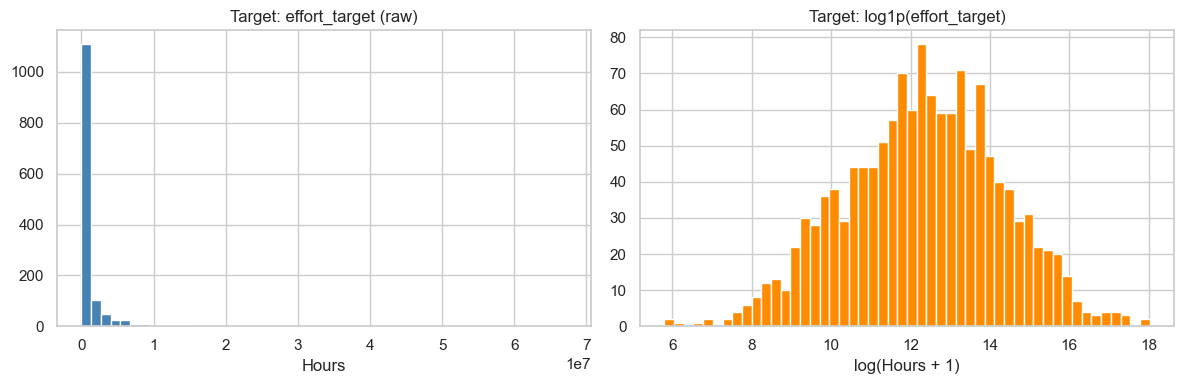

count    1.350000e+03
mean     1.250706e+06
std      3.908514e+06
min      3.275000e+02
25%      5.731502e+04
50%      2.308519e+05
75%      9.205723e+05
max      6.730578e+07
Name: effort_target, dtype: float64


In [7]:
# ── Target distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Target: effort_target (raw)')
axes[0].set_xlabel('Hours')

axes[1].hist(np.log1p(y), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Target: log1p(effort_target)')
axes[1].set_xlabel('log(Hours + 1)')

plt.tight_layout()
plt.show()

print(y.describe())

In [8]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = X_raw.isnull().sum()
missing = missing[missing > 0]
if len(missing):
    print('Missing values per column:')
    print(missing)
else:
    print('No missing values in feature set.')

Missing values per column:
language    22
dtype: int64


In [9]:
# ── Numeric feature distributions ────────────────────────────────────────────
num_cols = X_raw.select_dtypes(include='number').columns.tolist()
print(f'{len(num_cols)} numeric features')
X_raw[num_cols].describe().T[['mean','std','min','50%','max']].round(2)

23 numeric features


,mean,std,min,50%,max
stars,36796.62,39608.48,205.00,28171.00,443513.00
days_inactive,15.03,32.01,0.00,1.00,179.00
code_churn_normalized,60.02,0.07,60.00,60.00,61.11
pr_merge_time_median_h,27.22,137.96,0.00,8.47,4123.86
issues_resolution_time_h,180.76,431.03,0.00,43.48,6865.34
active_contributors,208.43,147.06,2.00,183.00,480.00
bus_factor_ratio,0.49,0.27,0.03,0.45,1.00
pr_count_merged,58.33,25.62,0.00,65.00,99.00
comment_per_pr_avg,0.00,0.00,0.00,0.00,0.00
closed_issues,1.00,0.00,1.00,1.00,1.00


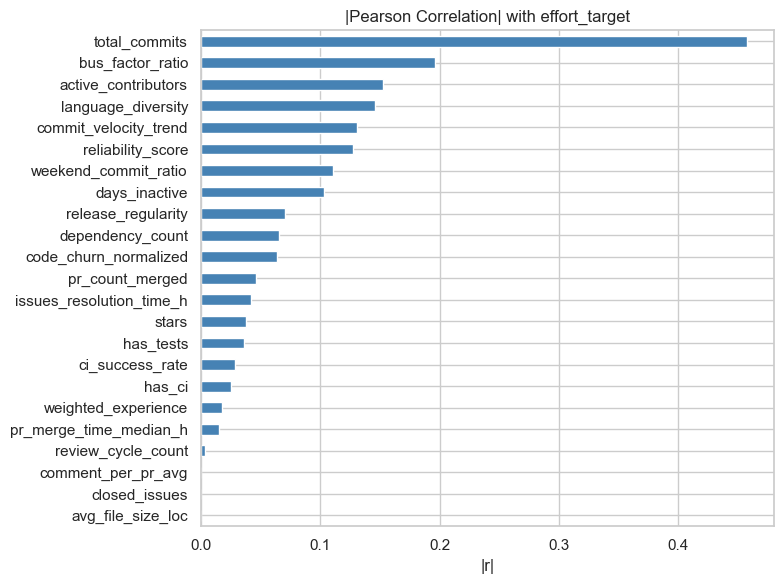

In [10]:
# ── Correlation with target ───────────────────────────────────────────────────
corr = X_raw[num_cols].corrwith(y).abs().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
corr.plot(kind='barh', color='steelblue')
plt.title('|Pearson Correlation| with effort_target')
plt.xlabel('|r|')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

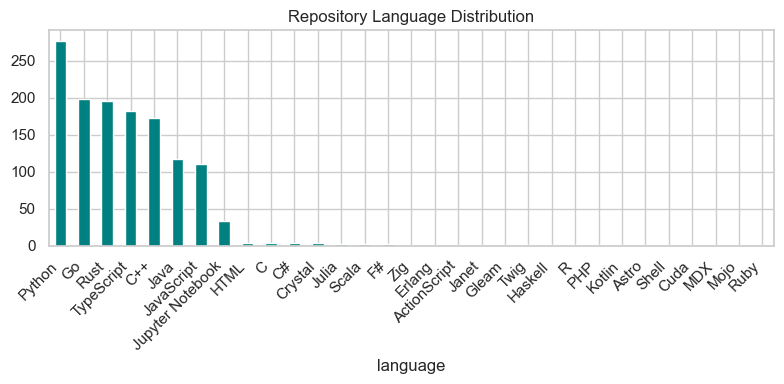

In [11]:
# ── Language distribution ─────────────────────────────────────────────────────
if 'language' in X_raw.columns:
    lang_counts = df['language'].value_counts()
    plt.figure(figsize=(8, 4))
    lang_counts.plot(kind='bar', color='teal', edgecolor='white')
    plt.title('Repository Language Distribution')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 4. Preprocessing

In [12]:
# ── Encode categorical features ───────────────────────────────────────────────
cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}')

X = X_raw.copy()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = X[col].fillna('unknown')
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# ── Log-transform the target (heavy right skew) ───────────────────────────────
y_log = np.log1p(y)

print(f'\nFinal feature matrix shape: {X.shape}')
print(f'Target skewness — raw: {y.skew():.2f}  |  log: {y_log.skew():.2f}')

Categorical columns: ['language']

Final feature matrix shape: (1350, 24)
Target skewness — raw: 8.82  |  log: -0.11


In [13]:
# ── Train/test split (80/20 stratified on log-binned target) ─────────────────
bins = pd.qcut(y_log, q=5, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42, stratify=bins
)

print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')

Train: 1080 rows  |  Test: 270 rows


In [14]:
# ── Preprocessing pipeline (impute then scale for linear models) ──────────────
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, X.columns.tolist())],
    remainder='passthrough'
)

## 5. Model Training & Cross-Validation

In [15]:
# ── Define models ─────────────────────────────────────────────────────────────
models = {
    'Ridge':            Pipeline([('pre', preprocessor), ('model', Ridge(alpha=10.0))]),
    'Lasso':            Pipeline([('pre', preprocessor), ('model', Lasso(alpha=0.01, max_iter=5000))]),
    'RandomForest':     Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(n_estimators=200, random_state=42))]),
    'GradientBoosting': Pipeline([('pre', preprocessor), ('model', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42))]),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=kf, scoring='neg_mean_absolute_error')
    r2 = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='r2')
    cv_results[name] = {
        'MAE_log_mean': -scores.mean(),
        'MAE_log_std':   scores.std(),
        'R2_mean':       r2.mean(),
        'R2_std':        r2.std(),
    }
    print(f'{name:20s}  CV MAE(log)={-scores.mean():.4f} ± {scores.std():.4f}  R²={r2.mean():.3f} ± {r2.std():.3f}')

Ridge                 CV MAE(log)=1.2908 ± 0.0472  R²=0.298 ± 0.061
Lasso                 CV MAE(log)=1.2889 ± 0.0439  R²=0.301 ± 0.058
RandomForest          CV MAE(log)=1.0950 ± 0.0559  R²=0.479 ± 0.038
GradientBoosting      CV MAE(log)=1.0710 ± 0.0722  R²=0.487 ± 0.060


In [16]:
# ── CV results summary ────────────────────────────────────────────────────────
cv_df = pd.DataFrame(cv_results).T.sort_values('R2_mean', ascending=False)
cv_df.round(4)

,MAE_log_mean,MAE_log_std,R2_mean,R2_std
GradientBoosting,1.0710,0.0722,0.4870,0.0601
RandomForest,1.0950,0.0559,0.4794,0.0384
Lasso,1.2889,0.0439,0.3008,0.0583
Ridge,1.2908,0.0472,0.2985,0.0607


## 6. Test Set Evaluation

In [17]:
def evaluate_model(pipeline, X_tr, y_tr, X_te, y_te, model_name):
    """Fit on train, evaluate on test. Reports metrics in log-space and original space."""
    pipeline.fit(X_tr, y_tr)
    pred_log = pipeline.predict(X_te)

    # Log-space metrics
    mae_log = mean_absolute_error(y_te, pred_log)
    r2_log  = r2_score(y_te, pred_log)

    # Original space metrics (expm1 to invert log1p)
    y_te_orig   = np.expm1(y_te)
    pred_orig   = np.expm1(pred_log)
    mae_orig    = mean_absolute_error(y_te_orig, pred_orig)
    rmse_orig   = np.sqrt(mean_squared_error(y_te_orig, pred_orig))
    mape        = np.mean(np.abs((y_te_orig - pred_orig) / (y_te_orig + 1e-9))) * 100
    r2_orig     = r2_score(y_te_orig, pred_orig)

    print(f'\n── {model_name} ──')
    print(f'  Log-space  :  MAE={mae_log:.4f}   R²={r2_log:.4f}')
    print(f'  Orig-space :  MAE={mae_orig:,.0f}h   RMSE={rmse_orig:,.0f}h   MAPE={mape:.1f}%   R²={r2_orig:.4f}')

    return {
        'pipeline':   pipeline,
        'pred_log':   pred_log,
        'pred_orig':  pred_orig,
        'y_te_orig':  y_te_orig,
        'metrics': {
            'MAE_log': mae_log, 'R2_log': r2_log,
            'MAE_h': mae_orig, 'RMSE_h': rmse_orig, 'MAPE_%': mape, 'R2': r2_orig
        }
    }

trained = {}
for name, pipeline in models.items():
    trained[name] = evaluate_model(pipeline, X_train, y_train, X_test, y_test, name)


── Ridge ──
  Log-space  :  MAE=1.2150   R²=0.3917
  Orig-space :  MAE=1,660,942h   RMSE=6,601,822h   MAPE=314.8%   R²=-0.7548

── Lasso ──
  Log-space  :  MAE=1.2106   R²=0.3976
  Orig-space :  MAE=1,514,540h   RMSE=5,439,941h   MAPE=306.0%   R²=-0.1915

── RandomForest ──
  Log-space  :  MAE=1.1053   R²=0.4872
  Orig-space :  MAE=1,109,858h   RMSE=4,523,939h   MAPE=175.5%   R²=0.1760

── GradientBoosting ──
  Log-space  :  MAE=1.0694   R²=0.5200
  Orig-space :  MAE=1,107,081h   RMSE=4,379,936h   MAPE=169.8%   R²=0.2276


In [18]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({k: v['metrics'] for k, v in trained.items()}).T
summary = summary.sort_values('R2', ascending=False)
summary.round(4)

,MAE_log,R2_log,MAE_h,RMSE_h,MAPE_%,R2
GradientBoosting,1.0694,0.5200,1.107081e+06,4.379936e+06,169.8062,0.2276
RandomForest,1.1053,0.4872,1.109858e+06,4.523939e+06,175.4900,0.1760
Lasso,1.2106,0.3976,1.514540e+06,5.439941e+06,306.0034,-0.1915
Ridge,1.2150,0.3917,1.660942e+06,6.601822e+06,314.7579,-0.7548


## 7. Best Model — Diagnostics

In [19]:
# ── Pick best model by R² ─────────────────────────────────────────────────────
best_name = summary.index[0]
best = trained[best_name]
print(f'Best model: {best_name}')

Best model: GradientBoosting


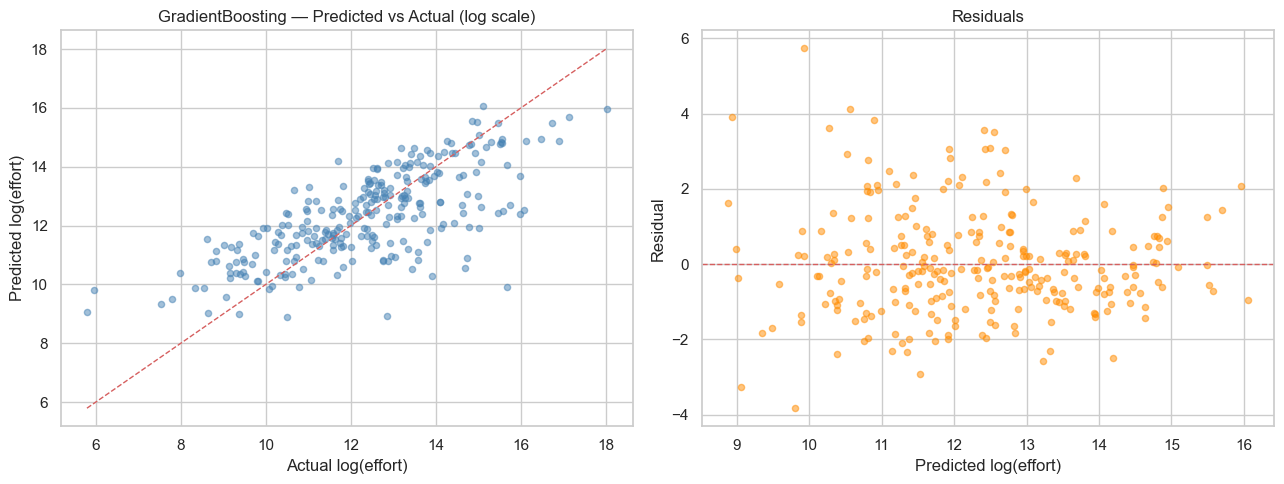

In [20]:
# ── Predicted vs Actual ───────────────────────────────────────────────────────
y_te_orig  = best['y_te_orig']
pred_orig  = best['pred_orig']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: log scale
axes[0].scatter(np.log1p(y_te_orig), np.log1p(pred_orig),
                alpha=0.5, s=20, color='steelblue')
lims = [min(np.log1p(y_te_orig).min(), np.log1p(pred_orig).min()),
        max(np.log1p(y_te_orig).max(), np.log1p(pred_orig).max())]
axes[0].plot(lims, lims, 'r--', lw=1)
axes[0].set_xlabel('Actual log(effort)')
axes[0].set_ylabel('Predicted log(effort)')
axes[0].set_title(f'{best_name} — Predicted vs Actual (log scale)')

# Residuals
residuals = np.log1p(y_te_orig) - np.log1p(pred_orig)
axes[1].scatter(np.log1p(pred_orig), residuals, alpha=0.5, s=20, color='darkorange')
axes[1].axhline(0, color='r', lw=1, ls='--')
axes[1].set_xlabel('Predicted log(effort)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals')

plt.tight_layout()
plt.show()

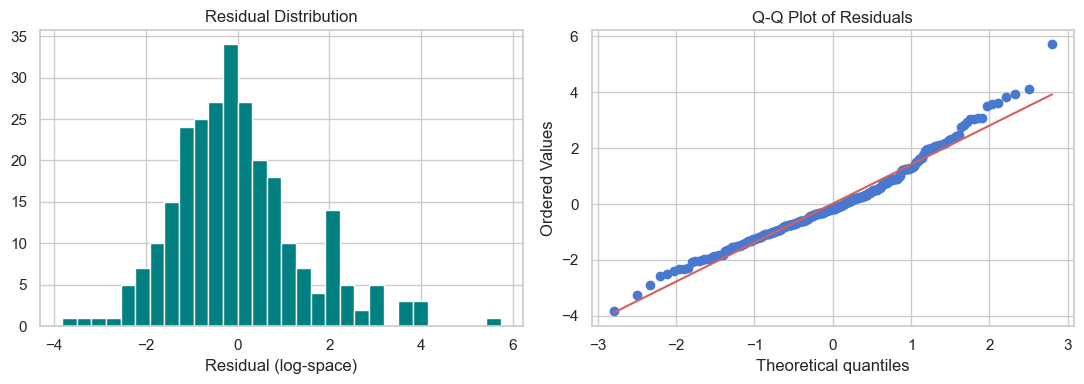

Shapiro-Wilk p-value: 0.0000  (Non-normal residuals)


In [21]:
# ── Residual normality check ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(residuals, bins=30, color='teal', edgecolor='white')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual (log-space)')

stats.probplot(residuals, plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

_, p = stats.shapiro(residuals)
print(f'Shapiro-Wilk p-value: {p:.4f}  ({"Normal" if p > 0.05 else "Non-normal"} residuals)')

## 8. Feature Importance

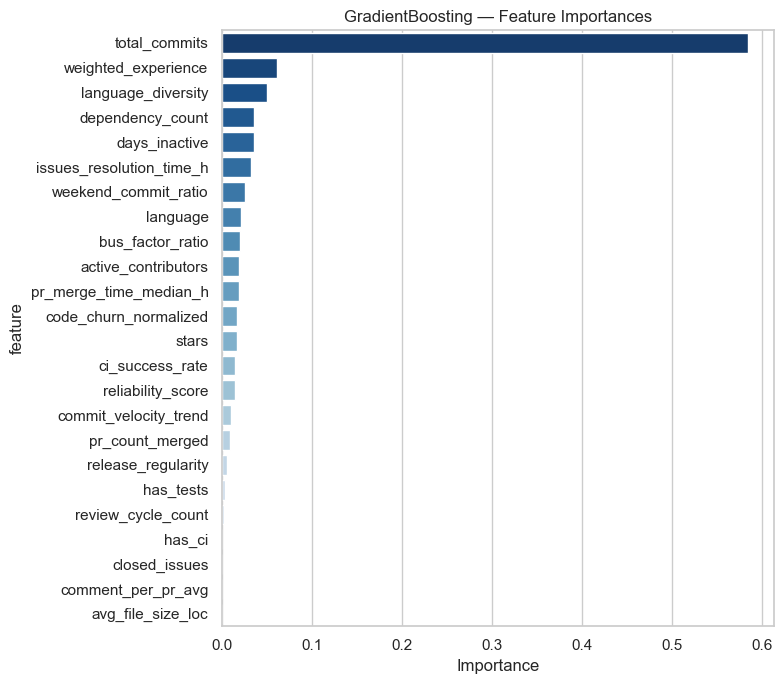

                 feature  importance
           total_commits    0.584034
     weighted_experience    0.061506
      language_diversity    0.049873
        dependency_count    0.035902
           days_inactive    0.035637
issues_resolution_time_h    0.032132
    weekend_commit_ratio    0.026290
                language    0.021285
        bus_factor_ratio    0.020462
     active_contributors    0.019386
  pr_merge_time_median_h    0.019314
   code_churn_normalized    0.017310
                   stars    0.016664
         ci_success_rate    0.014635
       reliability_score    0.014216
   commit_velocity_trend    0.010105
         pr_count_merged    0.009587
      release_regularity    0.005431
               has_tests    0.003335
      review_cycle_count    0.002139
                  has_ci    0.000760
           closed_issues    0.000000
      comment_per_pr_avg    0.000000
       avg_file_size_loc    0.000000


In [22]:
best_pipeline = best['pipeline']
best_estimator = best_pipeline.named_steps['model']

# ── Tree-based: built-in importance ──────────────────────────────────────────
if hasattr(best_estimator, 'feature_importances_'):
    imp = best_estimator.feature_importances_
    feat_df = pd.DataFrame({'feature': X.columns, 'importance': imp})\
                .sort_values('importance', ascending=False)

    plt.figure(figsize=(8, 7))
    sns.barplot(data=feat_df, x='importance', y='feature', palette='Blues_r')
    plt.title(f'{best_name} — Feature Importances')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    print(feat_df.to_string(index=False))

# ── Linear models: coefficients ───────────────────────────────────────────────
elif hasattr(best_estimator, 'coef_'):
    coef = pd.DataFrame({'feature': X.columns, 'coef': np.abs(best_estimator.coef_)})\
             .sort_values('coef', ascending=False)
    plt.figure(figsize=(8, 7))
    sns.barplot(data=coef, x='coef', y='feature', palette='Oranges_r')
    plt.title(f'{best_name} — |Coefficients|')
    plt.tight_layout()
    plt.show()

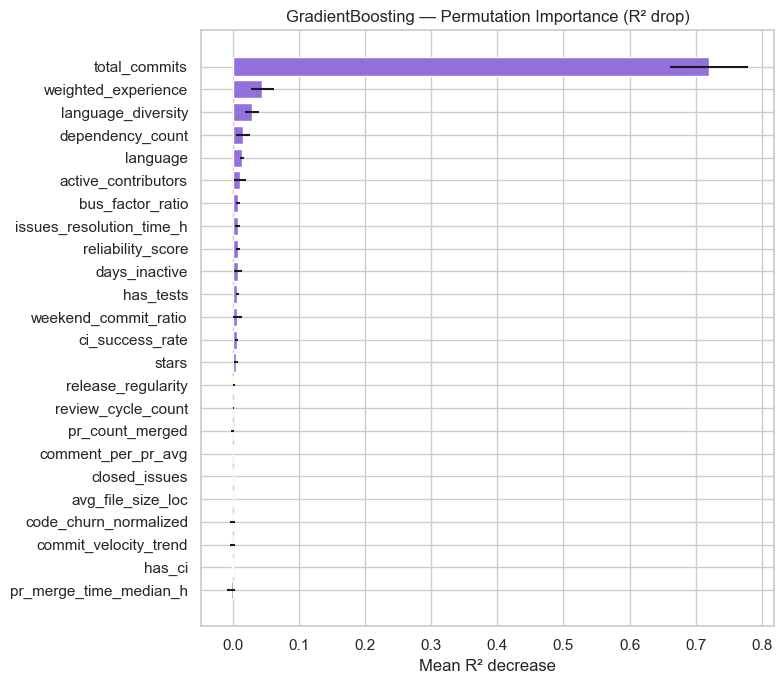

,feature,importance,std
22,total_commits,0.720298,0.058652
15,weighted_experience,0.044960,0.017394
20,language_diversity,0.028895,0.010448
19,dependency_count,0.015464,0.011100
0,language,0.014000,0.003115
6,active_contributors,0.011223,0.009572
7,bus_factor_ratio,0.008037,0.002709
5,issues_resolution_time_h,0.007896,0.003768
23,reliability_score,0.007703,0.003066
2,days_inactive,0.007471,0.005969


In [23]:
# ── Permutation importance (model-agnostic, on test set) ──────────────────────
# Transform test set through the preprocessing step only
X_test_pre = best_pipeline.named_steps['pre'].transform(X_test)

perm = permutation_importance(
    best_estimator, X_test_pre, y_test,
    n_repeats=15, random_state=42, scoring='r2'
)

perm_df = pd.DataFrame({
    'feature':    X.columns,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 7))
plt.barh(perm_df['feature'], perm_df['importance'],
         xerr=perm_df['std'], color='mediumpurple', edgecolor='white')
plt.title(f'{best_name} — Permutation Importance (R² drop)')
plt.xlabel('Mean R² decrease')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

perm_df.head(10)

## 9. Leakage Sanity Check

If any leak columns somehow end up in X, model R² on the test set would be unrealistically high (>0.99). This cell verifies none slipped through.

In [24]:
# ── Assert no leak column is in the feature matrix ────────────────────────────
leaked = [c for c in LEAK_COLS if c in X.columns]
if leaked:
    print(f'⚠️  LEAKAGE DETECTED: {leaked}')
else:
    print('✅ No leakage columns found in X.')

# ── R² sanity: warn if suspiciously perfect ──────────────────────────────────
best_r2 = best['metrics']['R2']
if best_r2 > 0.98:
    print(f'⚠️  Very high R²={best_r2:.4f} — double-check for residual leakage.')
else:
    print(f'✅ R²={best_r2:.4f} — looks realistic.')

✅ No leakage columns found in X.
✅ R²=0.2276 — looks realistic.


## 10. All Models — Comparison

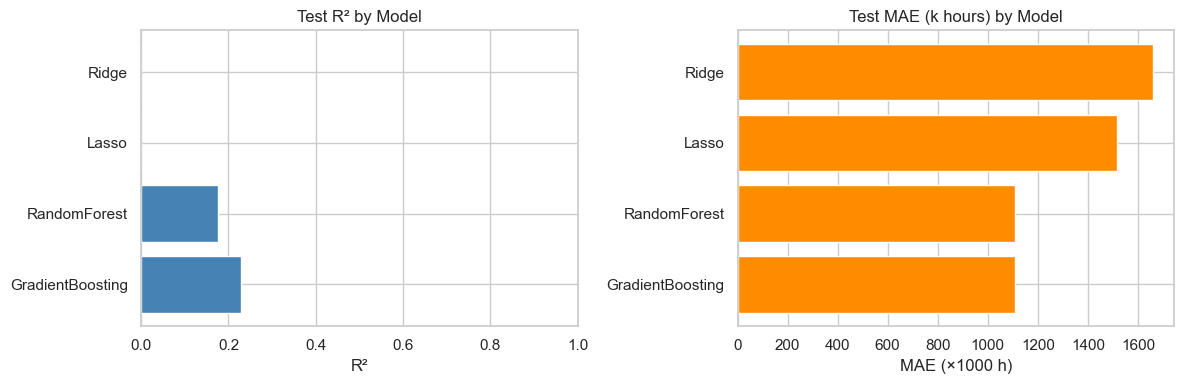


Full comparison table:


,MAE_log,R2_log,MAE_h,RMSE_h,MAPE_%,R2
GradientBoosting,1.07,0.52,1107080.95,4379936.40,169.81,0.23
RandomForest,1.11,0.49,1109857.55,4523939.21,175.49,0.18
Lasso,1.21,0.40,1514540.20,5439940.59,306.00,-0.19
Ridge,1.21,0.39,1660942.02,6601822.31,314.76,-0.75


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models_names = list(summary.index)
r2_vals  = summary['R2'].values
mae_vals = summary['MAE_h'].values

axes[0].barh(models_names, r2_vals, color='steelblue', edgecolor='white')
axes[0].set_title('Test R² by Model')
axes[0].set_xlabel('R²')
axes[0].set_xlim(0, 1)

axes[1].barh(models_names, mae_vals / 1000, color='darkorange', edgecolor='white')
axes[1].set_title('Test MAE (k hours) by Model')
axes[1].set_xlabel('MAE (×1000 h)')

plt.tight_layout()
plt.show()

print('\nFull comparison table:')
summary.round(2)